# Course Project
Team: ***The girls\* and the Bulat\*\* are doing projects***

We are exploring the contents of Vkusvill's catalog. This notebook contains the calculated analytics.

<br>
<br>*Барабанова Наталья Валерьевна, Никифорова Анна Дмитриевна, Зубаревич Ксения Владимировна
<br>**Файрушин Булат Рамилевич



In [1]:
#!pip install clickhouse-driver

In [1]:
# Установите библиотеку
# !pip install clickhouse-driver

from clickhouse_driver import Client
import pandas as pd

client = Client(
    host='158.160.231.239',
    port=9000,  # Для clickhouse_driver используйте порт 9000 (TCP), не 8123
    user='clickaa',
    password='susan090',
    secure=False
)

# Проверка
print(client.execute("SELECT version()"))

[('23.8.16.16',)]


In [ ]:
databases = client.execute("SHOW DATABASES")
print("Доступные базы данных:")
for db in databases:
    print(f"  - {db[0]}")

client.execute("USE default") 
tables = client.execute("SHOW TABLES")
print("\nТаблицы в базе 'default':")
for table in tables:
    print(f"  - {table[0]}")

query = "SELECT name, database, engine FROM system.tables WHERE database NOT IN ('system', 'INFORMATION_SCHEMA') LIMIT 10"
result = client.execute(query)
print("\nРезультат запроса:")
for row in result:
    print(row)


Доступные базы данных:
  - INFORMATION_SCHEMA
  - default
  - information_schema
  - system
  - vkusvill_db

Таблицы в базе 'default':
  - city

Результат запроса:
('city', 'default', 'MergeTree')
('COLUMNS', 'information_schema', 'View')
('SCHEMATA', 'information_schema', 'View')
('TABLES', 'information_schema', 'View')
('VIEWS', 'information_schema', 'View')
('columns', 'information_schema', 'View')
('schemata', 'information_schema', 'View')
('tables', 'information_schema', 'View')
('views', 'information_schema', 'View')
('products', 'vkusvill_db', 'MergeTree')


In [5]:
from clickhouse_driver import Client
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

client = Client(
    host='158.160.231.239',
    port=9000,
    user='clickaa',
    password='susan090'
)

query = "SELECT count(*) FROM vkusvill_db.products;"
result = client.execute(query)

print(result)
print("connection is checked")

print("data download...")
query = "SELECT * FROM vkusvill_db.products"
result = client.execute(query)
print("finished")

structure = client.execute("DESCRIBE vkusvill_db.products")
columns = [col[0] for col in structure]

[(751140,)]
connection is checked
data download...
finished


In [7]:
structure

[('title', 'String', '', '', '', '', ''),
 ('category', 'String', '', '', '', '', ''),
 ('subcategory', 'String', '', '', '', '', ''),
 ('price', 'Nullable(UInt32)', '', '', '', '', ''),
 ('price_unit', 'Nullable(String)', '', '', '', '', ''),
 ('weight', 'Nullable(String)', '', '', '', '', ''),
 ('rating', 'Nullable(Float32)', '', '', '', '', ''),
 ('description', 'Nullable(String)', '', '', '', '', ''),
 ('calories', 'Nullable(Float32)', '', '', '', '', ''),
 ('proteins', 'Nullable(Float32)', '', '', '', '', ''),
 ('fats', 'Nullable(Float32)', '', '', '', '', ''),
 ('carbs', 'Nullable(Float32)', '', '', '', '', ''),
 ('shelf_life', 'Nullable(String)', '', '', '', '', ''),
 ('brand', 'Nullable(String)', '', '', '', '', ''),
 ('storage_conditions', 'Nullable(String)', '', '', '', '', ''),
 ('manufacturer', 'Nullable(String)', '', '', '', '', ''),
 ('country', 'Nullable(String)', '', '', '', '', ''),
 ('composition', 'Nullable(String)', '', '', '', '', ''),
 ('labels', 'Nullable(String)

In [8]:
df = pd.DataFrame(result, columns=columns)
print(f"Загружено {len(df):,} записей")
print(f"Поля: {df.columns.tolist()}")


Загружено 751,140 записей
Поля: ['title', 'category', 'subcategory', 'price', 'price_unit', 'weight', 'rating', 'description', 'calories', 'proteins', 'fats', 'carbs', 'shelf_life', 'brand', 'storage_conditions', 'manufacturer', 'country', 'composition', 'labels', 'url', 'parsed_at']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751140 entries, 0 to 751139
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   title               751140 non-null  object        
 1   category            751140 non-null  object        
 2   subcategory         751140 non-null  object        
 3   price               747427 non-null  float64       
 4   price_unit          751140 non-null  object        
 5   weight              717926 non-null  object        
 6   rating              632908 non-null  float64       
 7   description         724310 non-null  object        
 8   calories            434979 non-null  float64       
 9   proteins            419947 non-null  float64       
 10  fats                408840 non-null  float64       
 11  carbs               399538 non-null  float64       
 12  shelf_life          750759 non-null  object        
 13  brand               672055 no

In [10]:
df['parsed_at'] = pd.to_datetime(df['parsed_at'])
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['weight'] = df['weight'].astype(str)

In [11]:
df.head(5)

,title,category,subcategory,price,price_unit,weight,rating,description,calories,proteins,...,carbs,shelf_life,brand,storage_conditions,manufacturer,country,composition,labels,url,parsed_at
0,"Смузи ""Киви-ананас"", 250 мл",Можно при диабете,Напитки без добавленного сахара,160.0,шт,250 мл,5.0,Натуральный фруктовый смузи заботливо приготов...,NaN,NaN,...,NaN,21 Суток Поставщики: ФРУТТИ ООО; ЗЕЛЁНАЯ КОМПА...,ВкусВилл,Хранить при температуре от 0 до 4 C° Поставщи...,"ООО ""ФРУТТИ"":Российская Федерация, 108825, гор...",РОССИЯ Поставщики: ФРУТТИ ООО; ЗЕЛЁНАЯ КОМПАНИ...,"ООО ""ФРУТТИ"":пюре киви (39%), сок ананасовый (...",None,https://vkusvill.ru/goods/smuzi-kivi-ananas-25...,2026-05-08 21:51:18
1,"Дорадо тушка в маринаде на гриле, шт.","Рыба, икра и морепродукты",Рыба жареная и на пару,715.0,шт,300 г,4.9,Деликатесную рыбу маринуют в подсолнечном масл...,178.199997,23.799999,...,1.4,ВКУСВИЛЛ АО: 72 Часа,ВкусВилл,ВКУСВИЛЛ АО: Хранить при температуре от 0 до 4...,None,ВКУСВИЛЛ АО: РОССИЯ;,"АО ""ВКУСВИЛЛ"":Дорадо (продукция аквакультуры) ...",None,https://vkusvill.ru/goods/dorado-tushka-v-mari...,2026-05-08 21:51:18
2,"Сыр ""Брынза Сербская"", 260 г",Сыры,"Фета, моцарелла и другие мягкие",266.0,шт,260 г - масса сыра 240 г,4.9,"Классический рассольный сыр, изготовленный из ...",197.100006,11.800000,...,2.6,PREDUZECE MLEKARA – UB DOO: 180 Суток,ВкусВилл,PREDUZECE MLEKARA – UB DOO: Хранить при темпер...,"PREDUZECE MLEKARA – UB DOO:14210, город Уб, ул...",PREDUZECE MLEKARA – UB DOO: СЕРБИЯ;,PREDUZECE MLEKARA – UB DOO:молоко пастеризован...,Творожная,https://vkusvill.ru/goods/syr-brynza-serbskaya...,2026-05-08 21:51:18
3,Вок фунчоза с креветками,Вторые блюда,Вторые блюда с рыбой и морепродуктами,328.0,шт,200 г,4.9,Стеклянная вермишель с нежным креветочным мясо...,87.000000,2.600000,...,15.1,ТПК БОНУС ООО: 4 Суток,ВкусВилл,ТПК БОНУС ООО: Хранить при температуре от 2 до...,"ООО ""ТПК ""БОНУС"":Россия, 127434, город Москва,...",ТПК БОНУС ООО: РОССИЯ;,"ООО ""ТПК ""БОНУС"":Вермишель фунчоза (гороховый ...","Без лука, Светофор",https://vkusvill.ru/goods/vok-funchoza-s-kreve...,2026-05-08 21:51:19
4,Онигири с запеченным тунцом,Готовая еда,Сэндвичи и пирожки,208.0,шт,100 г,4.8,Японский рисовый сэндвич с запечённым тунцом и...,NaN,NaN,...,NaN,"КУЛИНАРНАЯ ФАБРИКА ""КОРОЛЕВСКИЙ ВКУС"" ООО: 72 ...",ВкусВилл,Хранить при температуре от 2 до 6 C° Поставщи...,"ООО КУЛИНАРНАЯ ФАБРИКА ""КОРОЛЕВСКИЙ ВКУС"":Росс...","РОССИЯ Поставщики: КУЛИНАРНАЯ ФАБРИКА ""КОРОЛЕВ...","ООО КУЛИНАРНАЯ ФАБРИКА ""КОРОЛЕВСКИЙ ВКУС"":круп...",None,https://vkusvill.ru/goods/onigiri-s-zapechenny...,2026-05-08 21:51:19


## Динамика цены за кг

**Гиппотеза:** <span style="color: red;">отсутсвует</span>

<span style="color: red;">Здесь в основном смотрел максимальный размах цен (и убывание, и возрастание). Далее размах называю "нестабильностью"</span>

<span style="color: red;">Есть гистограмма распределения товаров по группам стабильности и соотношение стабильных и не очень товаров; и таблички с топами</span>

**<span style="color: red;">Итог раздела: размахи огромные, я им не верю</span>**

In [12]:
import re
def extract_weight_grams(weight_str):
    if pd.isna(weight_str) or not str(weight_str).strip():
        return np.nan

    text = str(weight_str).lower().replace(',', '.')

    try:
        # килограммы -> граммы
        match = re.search(r'(\d+(?:\.\d+)?)\s*кг', text)
        if match:
            return float(match.group(1)) * 1000

        # граммы
        match = re.search(r'(\d+(?:\.\d+)?)\s*г', text)
        if match:
            return float(match.group(1))

        # литры -> мл (условно как граммы для сравнения)
        match = re.search(r'(\d+(?:\.\d+)?)\s*л', text)
        if match:
            return float(match.group(1)) * 1000

        # миллилитры
        match = re.search(r'(\d+(?:\.\d+)?)\s*мл', text)
        if match:
            return float(match.group(1))

    except Exception:
        pass

    return np.nan

In [13]:
# Извлекаем вес
df['weight_grams'] = df['weight'].apply(extract_weight_grams)

# Исключаем нулевые и отрицательные значения
df.loc[df['weight_grams'] <= 0, 'weight_grams'] = np.nan

# Цена за грамм
df['price_per_gram'] = df['price'] / df['weight_grams']

# Цена за килограмм (обычно удобнее для анализа)
df['price_per_kg'] = df['price'] / (df['weight_grams'] / 1000)

# Убираем бесконечности
df[['price_per_gram', 'price_per_kg']] = (
    df[['price_per_gram', 'price_per_kg']]
    .replace([np.inf, -np.inf], np.nan)
)
df = df.sort_values(['url', 'parsed_at'])

print(f"\nПосле обработки: {len(df):,} записей")
print(f"Цена за грамм доступна для {df['price_per_gram'].notna().sum():,} товаров")
print(f"Цена за кг доступна для {df['price_per_kg'].notna().sum():,} товаров")

# Проверка нераспознанных весов
failed_weights = (
    df[df['weight_grams'].isna()]['weight']
    .value_counts()
    .head(200)
)

print("\nТоп-20 нераспознанных значений веса:")
print(failed_weights)


После обработки: 751,140 записей
Цена за грамм доступна для 669,100 товаров
Цена за кг доступна для 669,100 товаров

Топ-20 нераспознанных значений веса:
None            33214
1 уп            22965
1 шт            21118
20 шт             362
10 шт             332
150               109
4 шт               73
1 уп (20 шт)       72
350                66
1 шт/              37
1 упак             37
шт                 36
1упак              36
Name: weight, dtype: int64


In [14]:
print(df['weight'].dropna().head(20).tolist())
sample = df['weight'].dropna().iloc[0]
print(repr(sample))




['300 мл', '300 мл', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г', '40 г']
'300 мл'


In [15]:
for x in ['250 мл', '300 г', '200 г']:
    print(x, extract_weight_grams(x))

250 мл 250.0
300 г 300.0
200 г 200.0


In [16]:
# Работаем только с валидными значениями
price_df = df[
    df['price_per_kg'].notna()
].copy()

# Индексы строк с минимумом и максимумом
idx_min = price_df.groupby('url')['price_per_kg'].idxmin()
idx_max = price_df.groupby('url')['price_per_kg'].idxmax()

min_prices = (
    price_df.loc[idx_min,
                 ['url', 'title', 'price_per_kg',
                  'price', 'weight_grams', 'parsed_at']]
    .rename(columns={
        'price_per_kg': 'min_price_per_kg',
        'price': 'min_price',
        'weight_grams': 'min_weight',
        'parsed_at': 'min_date'
    })
)

max_prices = (
    price_df.loc[idx_max,
                 ['url', 'price_per_kg',
                  'price', 'weight_grams', 'parsed_at']]
    .rename(columns={
        'price_per_kg': 'max_price_per_kg',
        'price': 'max_price',
        'weight_grams': 'max_weight',
        'parsed_at': 'max_date'
    })
)

price_range = min_prices.merge(
    max_prices,
    on='url',
    how='inner'
)

In [17]:
price_range['growth_pct'] = (
    (price_range['max_price_per_kg']
     - price_range['min_price_per_kg'])
    / price_range['min_price_per_kg']
    * 100
)

price_range['growth_ratio'] = (
    price_range['max_price_per_kg']
    / price_range['min_price_per_kg']
)

In [18]:
top_growth = (
    price_range
    .sort_values('growth_pct', ascending=False)
    .head(20)
)

top_growth[
    [
        'title',
        'min_price_per_kg',
        'min_date',
        'max_price_per_kg',
        'max_date',
        'growth_pct'
    ]
]

,title,min_price_per_kg,min_date,max_price_per_kg,max_date,growth_pct
15543,"Печенье с предсказанием, 6 г",500.000000,2026-06-20 05:38:47,2833.333333,2026-05-18 09:49:57,466.666667
22284,Суши с авокадо,2800.000000,2026-05-26 22:53:11,14848.484848,2026-05-19 11:35:03,430.303030
5748,"Грибы лисички сушеные, 40 г",1975.000000,2026-06-20 05:46:13,9925.000000,2026-05-18 09:52:19,402.531646
10714,Лед пищевой (куб 5х5 см),58.000000,2026-05-18 10:01:07,290.000000,2026-05-29 19:36:51,400.000000
313,Ароматическое саше Chirton Лимонная свежесть 1...,1933.333333,2026-05-18 10:19:06,8133.333333,2026-06-01 13:48:35,320.689655
16574,"Пломбир ""Банан с клубникой"" в глазир. темн. шо...",140.000000,2026-06-06 14:55:42,550.000000,2026-05-18 10:02:49,292.857143
12278,Мицеллярный гель для умывания Himalaya since 1...,1060.000000,2026-05-18 10:18:28,3613.333333,2026-06-01 13:49:51,240.880503
9735,Крем-краска для волос Сьёсс Стойкое окрашивани...,1208.695652,2026-05-18 10:19:50,4104.347826,2026-06-01 13:47:36,239.568345
26031,"Завиток с корицей, зам. кафе",457.142857,2026-05-08 22:19:41,1542.857143,2026-05-13 20:29:02,237.500000
17211,"Пряник имбирный ""23 Февраля"" на палочке, 1 шт.",1550.000000,2026-06-13 12:33:40,5200.000000,2026-05-18 09:50:35,235.483871


Доступные стили matplotlib:
['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn']

Всего товаров в анализе: 25,523
Медианный рост цены: 0.0%
Средний рост цены: 3.7%

📊 АНАЛИЗ СТАБИЛЬНОСТИ ЦЕН ПО ГРУППАМ


,Товаров,"Доля, %"
0-5%,21651,84.83
5-10%,537,2.10
10-20%,1845,7.23
20-30%,676,2.65
30-50%,423,1.66
50-100%,339,1.33
100-200%,35,0.14
200-500%,17,0.07
500%+,0,0.00


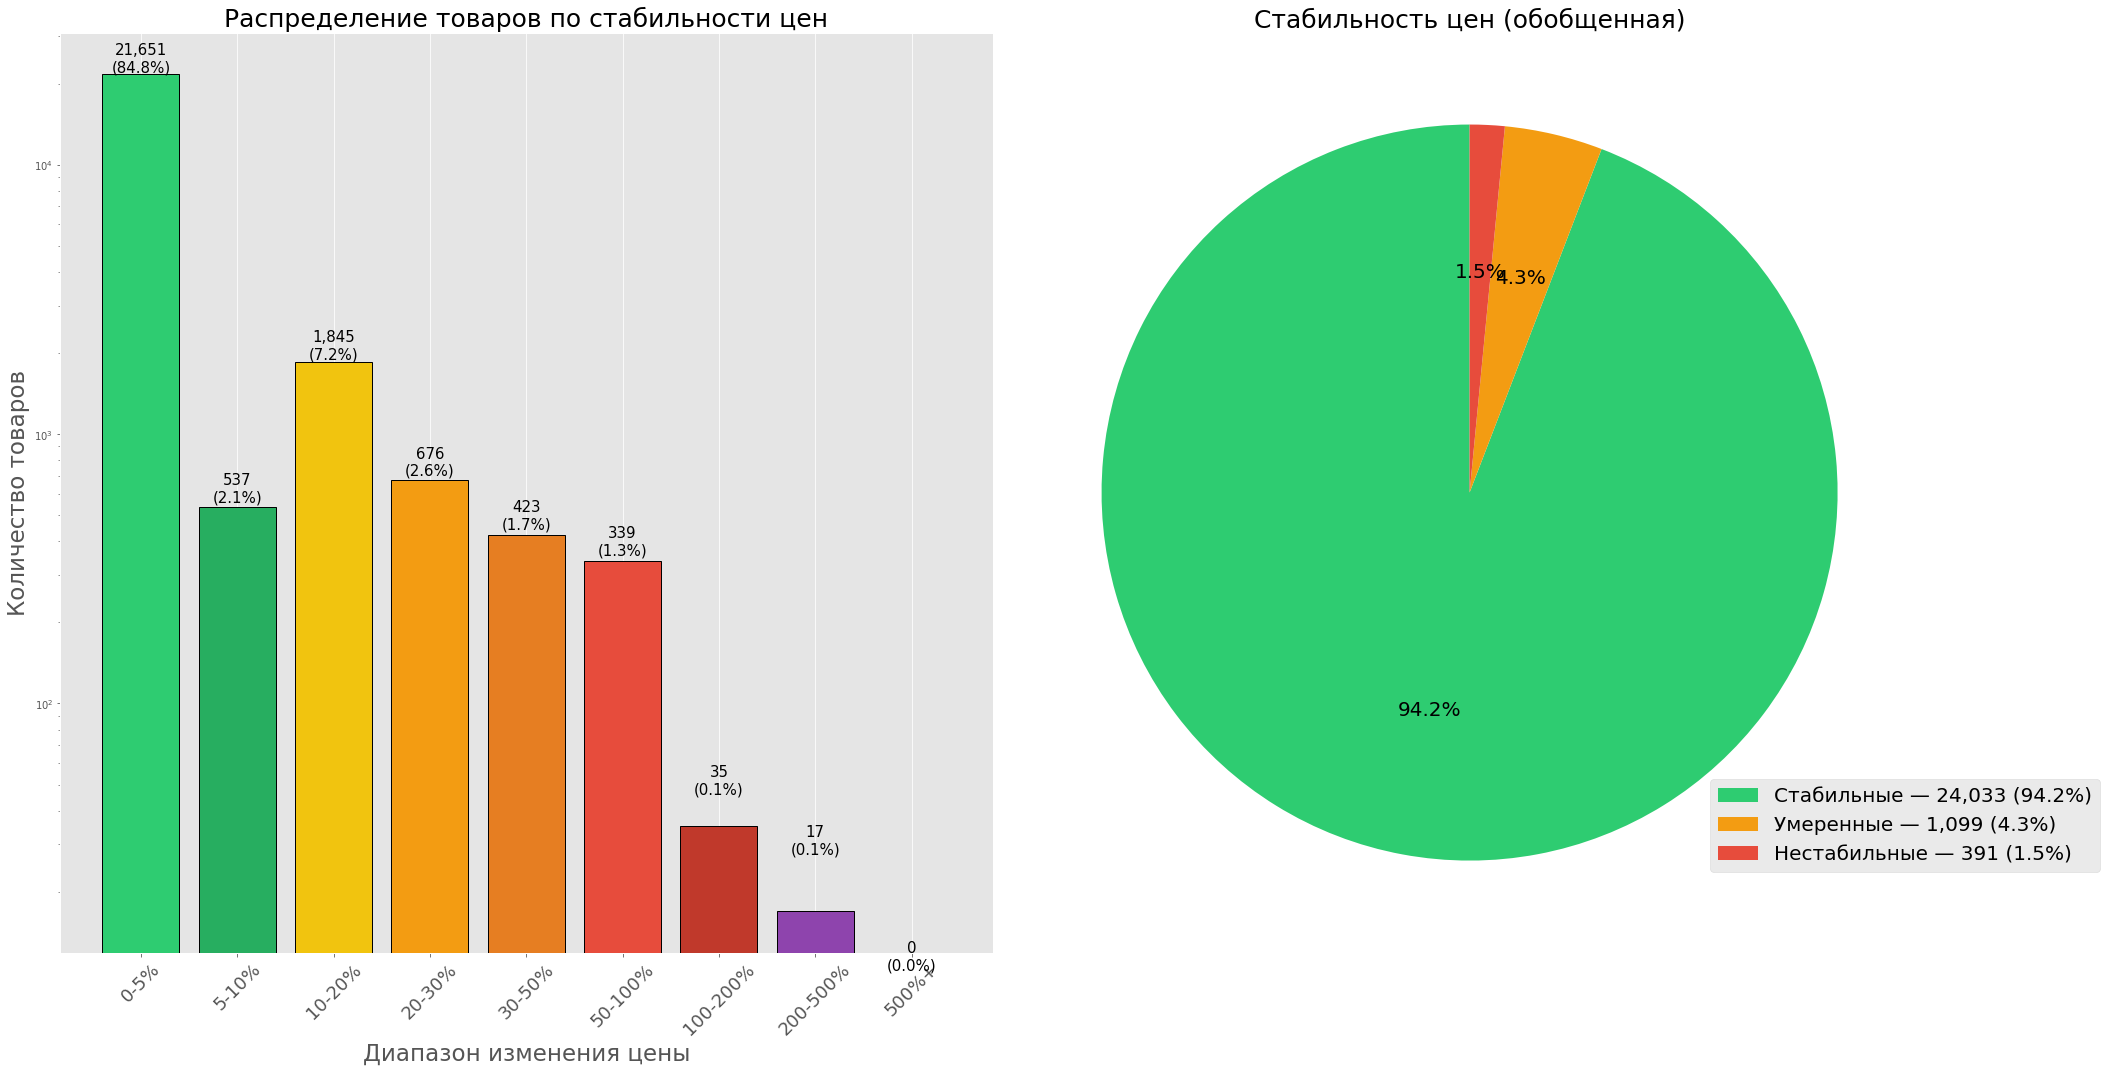


📈 ДЕТАЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ СТАБИЛЬНОСТИ


,count,avg_growth,median_growth,min_growth,max_growth,std_growth,avg_min_price,avg_max_price,avg_price_increase
stability_group,,,,,,,,,
0-5%,21651,0.07,0.00,0.0,4.96,0.47,2739.81,2741.02,1.21
5-10%,537,7.62,7.69,5.0,10.00,1.54,1691.51,1822.98,131.47
10-20%,1845,14.23,13.70,10.0,20.00,2.94,1602.58,1831.62,229.04
20-30%,676,24.57,24.78,20.0,30.00,2.79,1612.81,2008.50,395.69
30-50%,423,37.48,35.74,30.0,50.00,6.05,1562.98,2144.15,581.17
50-100%,339,65.39,66.67,50.0,99.37,9.62,2114.94,3486.31,1371.37
100-200%,35,120.17,115.24,100.0,179.20,22.41,2533.80,5249.23,2715.43
200-500%,17,283.91,237.50,202.0,466.67,86.39,1003.37,4044.90,3041.53
500%+,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



🏆 ТОП-10 САМЫХ СТАБИЛЬНЫХ ТОВАРОВ (мин. рост цены)


,title,min_price_per_kg,max_price_per_kg,min_date,max_date,growth_pct
0,39177,1000.000000,1000.000000,2026-06-03 22:08:06,2026-06-03 22:08:06,0.0
1,"5-HTP 100 мг, 60 растительных капсул / Здоровье",26050.000000,26050.000000,2026-05-08 21:51:53,2026-05-08 21:51:53,0.0
2,"5-HTP 100 мг, 60 растительных капсул / Здоровье",26050.000000,26050.000000,2026-05-18 09:39:44,2026-05-18 09:39:44,0.0
3,8in1 Жевательная коcточка для мелких собак S/...,11000.000000,11000.000000,2026-05-08 22:28:27,2026-05-08 22:28:27,0.0
4,"Абрикос, 500 г",976.000000,976.000000,2026-05-09 12:48:08,2026-05-09 12:48:08,0.0
5,"Абрикос, 500 г",976.000000,976.000000,2026-05-18 09:52:06,2026-05-18 09:52:06,0.0
6,"Абрикос Довча зеленый, 125 г",3080.000000,3080.000000,2026-05-18 09:52:37,2026-05-18 09:52:37,0.0
7,"Абрикос Довча зеленый, 125 г",3080.000000,3080.000000,2026-05-08 22:02:54,2026-05-08 22:02:54,0.0
8,"Абрикос Ферганский, 500 г",476.000000,476.000000,2026-06-11 22:06:00,2026-06-11 22:06:00,0.0
11,"Абрикос королевский ""ВВ Отборное"", 900 г",688.888889,688.888889,2026-06-14 13:22:35,2026-06-14 13:22:35,0.0



📈 ТОП-10 САМЫХ НЕСТАБИЛЬНЫХ ТОВАРОВ (макс. рост цены)


,title,min_price_per_kg,max_price_per_kg,min_date,max_date,growth_pct
15543,"Печенье с предсказанием, 6 г",500.000000,2833.333333,2026-06-20 05:38:47,2026-05-18 09:49:57,466.666667
22284,Суши с авокадо,2800.000000,14848.484848,2026-05-26 22:53:11,2026-05-19 11:35:03,430.303030
5748,"Грибы лисички сушеные, 40 г",1975.000000,9925.000000,2026-06-20 05:46:13,2026-05-18 09:52:19,402.531646
10714,Лед пищевой (куб 5х5 см),58.000000,290.000000,2026-05-18 10:01:07,2026-05-29 19:36:51,400.000000
313,Ароматическое саше Chirton Лимонная свежесть 1...,1933.333333,8133.333333,2026-05-18 10:19:06,2026-06-01 13:48:35,320.689655
16574,"Пломбир ""Банан с клубникой"" в глазир. темн. шо...",140.000000,550.000000,2026-06-06 14:55:42,2026-05-18 10:02:49,292.857143
12278,Мицеллярный гель для умывания Himalaya since 1...,1060.000000,3613.333333,2026-05-18 10:18:28,2026-06-01 13:49:51,240.880503
9735,Крем-краска для волос Сьёсс Стойкое окрашивани...,1208.695652,4104.347826,2026-05-18 10:19:50,2026-06-01 13:47:36,239.568345
26031,"Завиток с корицей, зам. кафе",457.142857,1542.857143,2026-05-08 22:19:41,2026-05-13 20:29:02,237.500000
17211,"Пряник имбирный ""23 Февраля"" на палочке, 1 шт.",1550.000000,5200.000000,2026-06-13 12:33:40,2026-05-18 09:50:35,235.483871



📊 СТАБИЛЬНОСТЬ ЦЕН ПО КАТЕГОРИЯМ

Топ-5 категорий с самой стабильной ценой (мин. медианный рост):


,avg_growth,median_growth,count,std_growth
category,,,,
Азиатская кухня,1.40,0.0,30,4.45
Мороженое,14.06,0.0,181,34.28
"Мука, ингредиенты для выпечки",5.01,0.0,51,8.94
Уход за губами,0.00,0.0,10,0.00
"Мюсли, хлопья, подушечки",10.26,0.0,44,16.46



Топ-5 категорий с самой нестабильной ценой (макс. медианный рост):


,avg_growth,median_growth,count,std_growth
category,,,,
Перчатки,24.83,24.83,6,27.20
Средства для посудомоечных машин,27.20,28.27,18,20.22
Детское мыло,27.24,29.88,6,24.56
Туалетная бумага,29.74,41.03,10,26.71
Зубные нити,41.70,41.70,2,58.98


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля - используем доступные стили
print("Доступные стили matplotlib:")
print(plt.style.available[:10])

# Используем стандартный стиль
plt.style.use('ggplot')  # или 'seaborn' если доступен
sns.set_palette("husl")

# Подготовим данные - используем уже созданный price_range
# Фильтруем выбросы (берем товары с разумным ростом, не более 500%)
price_range_filtered = price_range[
    (price_range['growth_pct'] >= 0) & 
    (price_range['growth_pct'] <= 500)
].copy()

print(f"\nВсего товаров в анализе: {len(price_range_filtered):,}")
print(f"Медианный рост цены: {price_range_filtered['growth_pct'].median():.1f}%")
print(f"Средний рост цены: {price_range_filtered['growth_pct'].mean():.1f}%")

'''# 1. ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ ПО ДИАПАЗОНАМ (10% шаг)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левая гистограмма - распределение по 10% интервалам
bins_10 = np.arange(0, 510, 10)  # от 0 до 500% с шагом 10%
counts_10, bins_edges_10 = np.histogram(price_range_filtered['growth_pct'], bins=bins_10)

# Строим столбчатую диаграмму
ax1 = axes[0]
bars = ax1.bar(bins_edges_10[:-1], counts_10, width=8, edgecolor='black', alpha=0.7)

# Цветовая градация от зеленого к красному
for i, bar in enumerate(bars):
    if i < len(bins_edges_10) // 3:
        bar.set_color('green')
    elif i < 2 * len(bins_edges_10) // 3:
        bar.set_color('orange')
    else:
        bar.set_color('red')

ax1.set_xlabel('Изменение цены за кг (рост, %)', fontsize=12)
ax1.set_ylabel('Количество товаров', fontsize=12)
ax1.set_title('Распределение товаров по росту цены\n(шаг 10%)', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы (только если столбец не пустой)
for i, v in enumerate(counts_10):
    if v > 0:
        ax1.text(bins_edges_10[i] + 5, v + 5, str(v), 
                ha='center', va='bottom', fontsize=8, rotation=90)

# 2. КУМУЛЯТИВНОЕ РАСПРЕДЕЛЕНИЕ
ax2 = axes[1]

# Сортируем и считаем кумулятивную сумму
sorted_data = np.sort(price_range_filtered['growth_pct'])
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100

ax2.plot(sorted_data, cumulative, linewidth=2.5, color='darkblue')
ax2.fill_between(sorted_data, 0, cumulative, alpha=0.3)

# Добавляем медианную линию
median = price_range_filtered['growth_pct'].median()
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Медиана (50%)')
ax2.axvline(x=median, color='red', linestyle='--', alpha=0.5)

ax2.set_xlabel('Изменение цены за кг (рост, %)', fontsize=12)
ax2.set_ylabel('Кумулятивный процент товаров', fontsize=12)
ax2.set_title('Кумулятивное распределение товаров\nпо росту цены', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
'''
# 3. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ГРУППАМ СТАБИЛЬНОСТИ
print("\n" + "="*70)
print("📊 АНАЛИЗ СТАБИЛЬНОСТИ ЦЕН ПО ГРУППАМ")
print("="*70)

# Создаем категории стабильности
bins = [0, 5, 10, 20, 30, 50, 100, 200, 500, float('inf')]
labels = ['0-5%', '5-10%', '10-20%', '20-30%', '30-50%', 
          '50-100%', '100-200%', '200-500%', '500%+']

price_range_filtered['stability_group'] = pd.cut(
    price_range_filtered['growth_pct'], 
    bins=bins, 
    labels=labels, 
    right=False, 
)

stability_counts = price_range_filtered['stability_group'].value_counts().sort_index()
stability_pct = (stability_counts / len(price_range_filtered) * 100).round(2)

stability_df = pd.DataFrame({
    'Товаров': stability_counts,
    'Доля, %': stability_pct
})

display(stability_df)

# 4. ВИЗУАЛИЗАЦИЯ СТАБИЛЬНОСТИ (разбивка по группам)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

# Столбчатая диаграмма
colors = ['#2ecc71', '#27ae60', '#f1c40f', '#f39c12', '#e67e22', 
          '#e74c3c', '#c0392b', '#8e44ad', '#2c3e50']

bars = ax1.bar(stability_counts.index, stability_counts.values, 
               color=colors[:len(stability_counts)], 
               edgecolor='black', linewidth=1)

# Добавляем значения и проценты
for i, (idx, val) in enumerate(zip(stability_counts.index, stability_counts.values)):
    pct = stability_pct[idx]
    ax1.text(i, val + 10, f'{val:,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize= 15)

ax1.set_xlabel('Диапазон изменения цены', fontsize=23)
ax1.set_ylabel('Количество товаров', fontsize=23)
ax1.set_title('Распределение товаров по стабильности цен', fontsize=25)
ax1.set_yscale('log')  # Логарифмическая шкала для лучшей визуализации
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', labelsize=18, rotation=45)

# Pie chart - доля стабильных vs нестабильных
stable = stability_counts.iloc[:3].sum()  # до 20%
medium = stability_counts.iloc[3:5].sum()  # 20-50%
unstable = stability_counts.iloc[5:].sum()  # >50%

total = len(price_range_filtered)
stable_pct = stable / total * 100
medium_pct = medium / total * 100
unstable_pct = unstable / total * 100
sizes = [stable, medium, unstable]
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
labels_pie = [
    f'Стабильные — {stable:,} ({stable_pct:.1f}%)',
    f'Умеренные — {medium:,} ({medium_pct:.1f}%)',
    f'Нестабильные — {unstable:,} ({unstable_pct:.1f}%)'
]

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=None,          # <-- убрать подписи вокруг круга
    autopct='%1.1f%%',    # оставить только проценты внутри
    startangle=90,
    colors=colors_pie,
    textprops={'fontsize': 20}
)

ax2.legend(
    wedges,
    labels_pie,
    loc='upper left',
    bbox_to_anchor=(0.75, 0.2),
    fontsize=20
)


# Добавляем проценты внутри
total = len(price_range_filtered)


ax2.set_title('Стабильность цен (обобщенная)', fontsize=25)

plt.tight_layout()
plt.show()

# 5. СТАТИСТИКА ПО СТАБИЛЬНОСТИ
print("\n" + "="*70)
print("📈 ДЕТАЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ СТАБИЛЬНОСТИ")
print("="*70)

stats_by_group = price_range_filtered.groupby('stability_group').agg({
    'growth_pct': ['count', 'mean', 'median', 'min', 'max', 'std'],
    'min_price_per_kg': 'mean',
    'max_price_per_kg': 'mean'
}).round(2)

stats_by_group.columns = ['count', 'avg_growth', 'median_growth', 'min_growth', 
                          'max_growth', 'std_growth', 'avg_min_price', 'avg_max_price']
stats_by_group['avg_price_increase'] = stats_by_group['avg_max_price'] - stats_by_group['avg_min_price']

display(stats_by_group)

# 6. ТОП-ТОВАРЫ ПО СТАБИЛЬНОСТИ
print("\n" + "="*70)
print("🏆 ТОП-10 САМЫХ СТАБИЛЬНЫХ ТОВАРОВ (мин. рост цены)")
print("="*70)

top_stable = price_range_filtered.nsmallest(10, 'growth_pct')
display(top_stable[['title', 'min_price_per_kg', 'max_price_per_kg', 
                    'min_date', 'max_date', 'growth_pct']])

print("\n" + "="*70)
print("📈 ТОП-10 САМЫХ НЕСТАБИЛЬНЫХ ТОВАРОВ (макс. рост цены)")
print("="*70)

top_unstable = price_range_filtered.nlargest(10, 'growth_pct')
display(top_unstable[['title', 'min_price_per_kg', 'max_price_per_kg', 
                      'min_date', 'max_date', 'growth_pct']])

# 7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ ПО КАТЕГОРИЯМ
print("\n" + "="*70)
print("📊 СТАБИЛЬНОСТЬ ЦЕН ПО КАТЕГОРИЯМ")
print("="*70)

# Добавляем категории к price_range_filtered
price_range_filtered_with_cat = price_range_filtered.merge(
    df[['url', 'category']].drop_duplicates('url'),
    on='url',
    how='left'
)

# Статистика по категориям
category_stability = price_range_filtered_with_cat.groupby('category').agg({
    'growth_pct': ['mean', 'median', 'count', 'std']
}).round(2)

category_stability.columns = ['avg_growth', 'median_growth', 'count', 'std_growth']
category_stability = category_stability.sort_values('median_growth')

print("\nТоп-5 категорий с самой стабильной ценой (мин. медианный рост):")
display(category_stability.head(5))

print("\nТоп-5 категорий с самой нестабильной ценой (макс. медианный рост):")
display(category_stability.tail(5))

<span style="color: red;">Ниже для формальности приведу топы подешевевших и подорожавших товаров среди тех, которые были доступны и в первый, и в последний дни парсинга (ВАЖНО: ГРУППИРОВКА ПО URL даёт пустое пересечение)</span>

In [20]:
# границы периода
first_date = df['parsed_at'].dt.date.min()
last_date = df['parsed_at'].dt.date.max()

print(first_date, last_date)

# товары в первый день
first_day = (
    df[df['parsed_at'].dt.date == first_date]
    .sort_values('parsed_at')
    .groupby('title') 
    .last()
    .reset_index()
    [['url', 'title', 'price', 'price_per_kg']]
    .rename(columns={
        'price': 'price_first',
        'price_per_kg': 'price_per_kg_first'
    })
)
print(len(first_day))
# товары в последний день
last_day = (
    df[df['parsed_at'].dt.date == last_date]
    .sort_values('parsed_at')
    .groupby('title')
    .last()
    .reset_index()
    [['url', 'title', 'price', 'price_per_kg']]
    .rename(columns={
        'price': 'price_last',
        'price_per_kg': 'price_per_kg_last'
    })
)
print(len(last_day))

# только товары, которые были и в начале, и в конце
price_change = (
    first_day
    .merge(
        last_day[['url', 'title', 'price_last', 'price_per_kg_last']],
        on='title',
        how='inner'
    )
)


print(len(price_change))

# изменение цены
price_change['price_diff'] = (
    price_change['price_last']
    - price_change['price_first']
)

price_change['price_pct'] = (
    price_change['price_diff']
    / price_change['price_first']
    * 100
)

# изменение цены за кг
price_change['price_per_kg_diff'] = (
    price_change['price_per_kg_last']
    - price_change['price_per_kg_first']
)

price_change['price_per_kg_pct'] = (
    price_change['price_per_kg_diff']
    / price_change['price_per_kg_first']
    * 100
)

2026-05-08 2026-06-21
15918
12755
11733


In [21]:
top_risers_kg = (
    price_change
    .dropna(subset=['price_per_kg_pct'])
    .sort_values('price_per_kg_pct', ascending=False)
    [[
        'title',
        'price_per_kg_first',
        'price_per_kg_last',
        'price_per_kg_pct'
    ]]
    .head(20)
)

top_fallers_kg = (
    price_change
    .dropna(subset=['price_per_kg_pct'])
    .sort_values('price_per_kg_pct')
    [[
        'title',
        'price_per_kg_first',
        'price_per_kg_last',
        'price_per_kg_pct'
    ]]
    .head(20)
)

In [22]:
top_risers_kg

,title,price_per_kg_first,price_per_kg_last,price_per_kg_pct
4396,Лед пищевой (куб 5х5 см),58.000000,290.000000,400.000000
252,Ароматическое саше Chirton Лимонная свежесть 1...,1933.333333,8133.333333,320.689655
5124,Мицеллярный гель для умывания Himalaya since 1...,1060.000000,3613.333333,240.880503
4033,Крем-краска для волос Сьёсс Стойкое окрашивани...,1208.695652,4104.347826,239.568345
1921,"Завиток с корицей, зам. кафе",457.142857,1542.857143,237.500000
4560,Лёд из пюре Дыни,400.000000,1300.000000,225.000000
2077,Зубная паста Himalaya Since 1930 Свежая мята 7...,1986.666667,5026.666667,153.020134
4007,Крем для лица рук и тела Himalaya since 1930 П...,1986.666667,4880.000000,145.637584
3336,Кондиционер для белья Hygiene Цветок пиона пар...,872.916667,1954.166667,123.866348
3333,Кондиционер для белья BioMio Bio-Soft Апельсин...,373.750000,815.000000,118.060201


In [23]:

top_fallers_kg

,title,price_per_kg_first,price_per_kg_last,price_per_kg_pct
6855,"Печенье с предсказанием, 6 г",2833.333333,500.000000,-82.352941
5735,"Напиток ""Фруктовый сюрприз"" с грушей и виногра...",336.000000,66.666667,-80.158730
1616,"Грибы лисички сушеные, 40 г",9925.000000,1975.000000,-80.100756
9275,Суши с форелью,17000.000000,3400.000000,-80.000000
7142,"Пломбир ""Банан с клубникой"" в глазир. темн. шо...",690.000000,140.000000,-79.710145
7437,"Пряник имбирный ""23 Февраля"" на палочке, 1 шт.",5200.000000,1550.000000,-70.192308
11724,"Яйцо шок. ""Мега-удовольствие"" с карамел. шариками",4726.315789,1415.789474,-70.044543
11457,"Шоколад молочный ""Медаль с 1 сентября""",5200.000000,1560.000000,-70.000000
11723,"Яйцо шок. ""Кроличий переполох"" с карамел. шари...",6550.000000,1975.000000,-69.847328
5862,"Напиток молочный кофейный стерилизованный ""КОФ...",702.040816,212.244898,-69.767442



<span style="color: red;">Итог раздела: размахи огромные, я им не верю</span>

# Рейтинг
**гипотеза**: товары с низким рейтингом вероятнее всего удалят
снимут с продажи


<span style="color: red;">Мб норм, но можно усилить. Надо отредачить порядок</span>

In [24]:
df['prev_rating'] = df.groupby('url')['rating'].shift(1)


df['rating_delta'] = (
    df['rating'] - df['prev_rating']
) 

**Топ подъёма рейтинга за один шаг (разница между соседними измерениями)**

In [25]:

top_growth = (
    df[df['rating_delta'].notna()]
    .sort_values('rating_delta', ascending=False)
    [['title',
      'parsed_at',
      'prev_rating',
      'rating',
      'rating_delta']]
    .head(20)
)

top_growth

,title,parsed_at,prev_rating,rating,rating_delta
268514,"Пломбир ""Вишня с шоколадным соусом""",2026-05-25 00:22:14,2.7,3.9,1.2
677515,Тефтели из мяса цыплят-бройлеров с рисом,2026-06-18 06:00:39,4.0,4.8,0.8
141085,Соба с цыпленком,2026-05-17 11:27:26,4.0,4.7,0.7
262728,Говяжьи тефтели в томатном соусе с гречкой и г...,2026-05-25 00:06:13,4.1,4.7,0.6
519050,"Круассан ""Сан-Себастьян"" в форме лодочки",2026-06-08 13:14:56,4.0,4.6,0.6
100096,"Мороженое сливочное ""Пралине""",2026-05-13 20:23:37,4.3,4.9,0.6
280125,"Гвоздика в горшочке, шт",2026-05-25 00:57:13,3.9,4.4,0.5
556660,Говядина в томатном соусе с кабачками гриль и ...,2026-06-11 21:56:00,4.0,4.5,0.5
245017,Арбуз Иран,2026-05-22 20:53:17,3.9,4.4,0.5
557560,"Говядина ""Терияки"" с запеченными овощами",2026-06-11 21:59:01,4.0,4.5,0.5


**Топ падения рейта за один шаг (разница между соседними измерениями)**

In [26]:
top_drop = (
    df[df['rating_delta'].notna()]
    .sort_values('rating_delta')
    [['title',
      'parsed_at',
      'prev_rating',
      'rating',
      'rating_delta']]
    .head(20)
)

top_drop

,title,parsed_at,prev_rating,rating,rating_delta
381814,Галета с персиками и творогом,2026-05-31 21:28:01,4.1,3.0,-1.1
81514,Хлеб Самарский Хлебозавод №5 Тостовый молочный...,2026-05-11 23:04:09,5.0,4.0,-1.0
228617,"Пломбир ""Вишня с шоколадным соусом""",2026-05-21 19:00:13,3.6,2.6,-1.0
354035,Филе грудки индейки Инди Лайт обжаренное на гр...,2026-05-29 19:57:01,4.9,4.0,-0.9
80215,Коктейль молочный Чабан Шоколадный канистра 95...,2026-05-11 23:01:09,4.9,4.0,-0.9
351171,Сыр мягкий President Бри с белой плесенью 60% ...,2026-05-29 19:51:28,4.9,4.0,-0.9
382662,Микс цукини и перцев для гриля,2026-05-31 21:30:20,4.9,4.0,-0.9
600159,"Голубика, 300 г",2026-06-13 12:37:50,4.9,4.0,-0.9
341879,Омлет с сыром и шпинатом,2026-05-29 19:20:12,4.9,4.0,-0.9
441628,"Пряники ""На кефире""",2026-06-03 22:00:27,4.9,4.0,-0.9


In [27]:
product_rating = (
    df.groupby('url')
      .agg(
          title=('title', 'first'),

          first_rating=('rating', 'first'),
          last_rating=('rating', 'last'),

          min_rating=('rating', 'min'),
          max_rating=('rating', 'max'),

          first_seen=('parsed_at', 'min'),
          last_seen=('parsed_at', 'max'),

          observations=('url', 'size')
      )
      .reset_index()
)

product_rating = product_rating[
    product_rating['observations'] >= 10
]

In [28]:
product_rating['rating_change'] = (
    product_rating['last_rating']
    - product_rating['first_rating']
)

product_rating['rating_drop'] = (
    product_rating['max_rating']
    - product_rating['min_rating']
)

**Топ падения**

In [29]:
top_fallers = (
    product_rating
    .sort_values('rating_change')
    [['title',
      'first_rating',
      'last_rating',
      'rating_change',
      'observations']]
    .head(50)
)

top_fallers

,title,first_rating,last_rating,rating_change,observations
9620,Колбаса сырокопченая Иней Салями зернистая нар...,5.0,4.0,-1.0,10
8128,Кексы-мини ванильно-сливочные с изюмом,4.9,4.0,-0.9,12
24829,Соус Шримайо,4.9,4.0,-0.9,58
12071,Лапша гречневая с цукини и ореховым соусом,4.9,4.0,-0.9,45
13668,"Масса творожная с ванилью обезжиренная, 90 г",4.9,4.0,-0.9,13
23622,Слайсы из филе грудки цыпленка-бройлера,4.9,4.0,-0.9,26
20065,"Пряники ""На кефире""",4.9,4.0,-0.9,30
11525,"Круассан с форелью и сливочным крем-чизом, кафе",4.9,4.0,-0.9,18
5577,Галета с персиками и творогом,3.9,3.0,-0.9,18
16969,Основа для Римской пиццы Festa замороженная 20...,4.9,4.0,-0.9,52


**Топ подъема**

In [30]:
top_risers = (
    product_rating
    .sort_values('rating_change', ascending=False)
    [['title',
      'first_rating',
      'last_rating',
      'rating_change',
      'observations']]
    .head(50)
)

top_risers

,title,first_rating,last_rating,rating_change,observations
23648,"Слива Узбекистан, 500 г",3.0,4.4,1.4,26
26781,"Темпура ролл ""Хот-дог"" с гуакамоле",4.0,4.8,0.8,30
5593,Гаспачо огуречный с базиликом и креветкой,3.7,4.3,0.6,48
3043,"Черешня розовая, 500 г",3.8,4.4,0.6,15
15457,"Напиток ""0 калорий"" со вкусом персика, газиров...",3.8,4.4,0.6,76
386,Арбуз новый урожай,3.8,4.4,0.6,10
6066,"Говядина ""Терияки"" с запеченными овощами",3.9,4.5,0.6,18
6087,Говядина в томатном соусе с кабачками гриль и ...,4.1,4.7,0.6,37
12321,"Лаваш с куриным шницелем, овощами и зеленью",3.9,4.5,0.6,16
3988,Дорадо на гриле,4.3,4.8,0.5,71


In [31]:
max_date = df['parsed_at'].max()

max_date

Timestamp('2026-06-21 08:31:30')

In [32]:
product_rating['days_absent'] = (
    max_date - product_rating['last_seen']
).dt.days

In [33]:
product_rating['removed'] = (
    product_rating['days_absent'] > 7
)

**вторая гиппотеза: низкий рейтинг -- главная причина снятия с продаж** <span style="color: red;">этот блок надо сместить ниже</span>

In [34]:
product_rating.groupby('removed').agg(
    avg_change=('rating_change', 'mean'),
    avg_drop=('rating_drop', 'mean'),
    products=('url', 'count')
)

,avg_change,avg_drop,products
removed,,,
False,-0.001902,0.137632,12846
True,-0.010897,0.090642,5401


Из таблицы следует, что среди товаров снятых с продажи и продающихся среднее изменение в цене ( разница между первым и последним втреченным рейтингом на сайте, максимальное падение) отличается на сотые балла. Рейтинг точно не является определяющим фактором для удаления товара.

In [35]:
product_rating_clean = product_rating[
    product_rating['max_rating'].notna()
]
removed_products = (
    product_rating_clean
    .query('removed == True')
    .sort_values('rating_change')
    [['title',
      'first_rating',
      'last_rating',
      'rating_change',
      'days_absent']]
)

removed_products.head(10)

,title,first_rating,last_rating,rating_change,days_absent
9620,Колбаса сырокопченая Иней Салями зернистая нар...,5.0,4.0,-1.0,22
14223,Молоко Братья Чебурашкины питьевое пастеризова...,4.9,4.0,-0.9,20
8128,Кексы-мини ванильно-сливочные с изюмом,4.9,4.0,-0.9,40
11525,"Круассан с форелью и сливочным крем-чизом, кафе",4.9,4.0,-0.9,23
12071,Лапша гречневая с цукини и ореховым соусом,4.9,4.0,-0.9,17
25982,Сыр мягкий President Бри с белой плесенью 60% ...,4.9,4.0,-0.9,21
20065,"Пряники ""На кефире""",4.9,4.0,-0.9,17
13668,"Масса творожная с ванилью обезжиренная, 90 г",4.9,4.0,-0.9,19
5577,Галета с персиками и творогом,3.9,3.0,-0.9,19
5580,"Галета со сливой, 160 г",4.8,4.0,-0.8,12


In [36]:
product_rating_clean.groupby('removed').agg(
    mean_last_rating=('last_rating', 'mean'),
    median_last_rating=('last_rating', 'median'),
    min_last_rating=('last_rating', 'min'),
    count=('url', 'count')
)

,mean_last_rating,median_last_rating,min_last_rating,count
removed,,,,
False,4.824020,4.9,3.7,11041
True,4.814604,4.8,3.0,4937


*Таблица показывает, что большинство удалённых товаров имеет высокий рейтинг, что ещё раз подтверждает не состоятельность рейтинга как основной причины удаления товара*



<span style="color: red;">Далее код, который непосредсвенно проверяет основную гипотезу раздела. Позже подниму его выше. Ночью боялся сломать код</span>


In [37]:
bins = [0, 4.0, 4.3 , 4.5, 4.7, 4.8, 4.9, 5.0]

product_rating_clean['rating_bucket'] = pd.cut(
    product_rating_clean['last_rating'],
    bins=bins
)

In [38]:
rating_risk = (
    product_rating_clean
    .groupby('rating_bucket', observed=True)
    .agg(
        products=('url', 'count'),
        removed_rate=('removed', 'mean')
    )
)

rating_risk

,products,removed_rate
rating_bucket,,
"(0.0, 4.0]",79,0.607595
"(4.0, 4.3]",36,0.500000
"(4.3, 4.5]",420,0.304762
"(4.5, 4.7]",2700,0.310370
"(4.8, 4.9]",4693,0.316003
"(4.9, 5.0]",8050,0.300870


**В таблице показана доля товаров, которые были удалены из ассортимента, для различных диапазонов рейтинга.**

Гипотеза о связи низкого рейтинга с удалением товара подтверждается.

Для товаров с рейтингом выше **4.3** вероятность удаления остаётся практически постоянной и составляет около **30%**, независимо от дальнейшего роста рейтинга.

Однако после снижения рейтинга до **4.3 и ниже** вероятность удаления резко возрастает:

* рейтинг **≤ 4.0** → вероятность удаления **60.8%**;
* рейтинг **4.0–4.3** → вероятность удаления **50.0%**;
* рейтинг **> 4.3** → вероятность удаления около **30%**.

Таким образом, рейтинг не влияет линейно на вероятность удаления товара, но наблюдается **пороговый эффект**: после падения рейтинга ниже **4.3** товар значительно чаще выводится из ассортимента.


In [39]:
product_rating_clean['low_rating'] = (
    product_rating_clean['last_rating'] <= 4.3
)

pd.crosstab(
    product_rating_clean['low_rating'],
    product_rating_clean['removed'],
    normalize='index'
)

removed,False,True
low_rating,,
False,0.692933,0.307067
True,0.426087,0.573913


In [40]:
from scipy.stats import fisher_exact

tab = pd.crosstab(
    product_rating_clean['low_rating'],
    product_rating_clean['removed']
)

oddsratio, pvalue = fisher_exact(tab)

print('odds ratio:', oddsratio)
print('p-value:', pvalue)

odds ratio: 3.0395300801494893
p-value: 5.2897474531509074e-09


Дополнительная статистическая проверка показала, что товары с рейтингом **≤ 4.3** имеют примерно **в 3 раза более высокие шансы на удаление** по сравнению с товарами с рейтингом выше **4.3** (*Odds Ratio = 3.04, p-value < 0.001*). Это свидетельствует о статистически значимой связи между низким рейтингом и риском вывода товара из ассортимента.

Полученные результаты позволяют предположить, что рейтинг используется не как фактор ранжирования всех товаров, а как механизм выявления проблемных позиций. Пока рейтинг остаётся выше порогового значения, вероятность удаления практически не меняется, однако после его снижения ниже 4.3 риск вывода товара из ассортимента существенно возрастает.



<span style="color: red;">Далее проверял есть ли определённый промежуток времени за который товар с низким рейтингом уберут, но мне результат не нравится. </span>

In [41]:
THRESHOLD = 4.3 # здесь отчёт от первого занижения ниже 4.3
first_low_rating = (
    df[df['rating'] <= THRESHOLD]
    .groupby('url')
    .agg(
        first_low_date=('parsed_at', 'min')
    )
)
removed_products = product_rating_clean[
    product_rating_clean['removed']
][['url', 'title', 'last_seen']]


reaction = (
    removed_products
    .merge(
        first_low_rating,
        on='url',
        how='inner'
    )
)

reaction['reaction_days'] = (
    reaction['last_seen']
    - reaction['first_low_date']
).dt.days

In [42]:
reaction['reaction_days'].describe()

count    73.000000
mean      4.164384
std       5.382620
min       0.000000
25%       0.000000
50%       0.000000
75%       8.000000
max      25.000000
Name: reaction_days, dtype: float64

In [43]:
reaction['reaction_days'].median()

0.0

In [44]:
reaction['reaction_days'].mean()

4.164383561643835

In [45]:
last_low_rating = ( # здесь отчёт от последнего занижения ниже 4.3
    df[df['rating'] <= THRESHOLD]
    .groupby('url')
    .agg(
        last_low_date=('parsed_at', 'max')
    )
)
reaction = (
    removed_products
    .merge(
        last_low_rating,
        on='url'
    )
)

reaction['reaction_days'] = (
    reaction['last_seen']
    - reaction['last_low_date']
).dt.days

reaction['reaction_days'].describe(
    percentiles=[0.25, 0.5, 0.75]
)

count    73.000000
mean      0.917808
std       2.413811
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      12.000000
Name: reaction_days, dtype: float64



<span style="color: red;">Я полагаю, что надо строить временные ряды и расчитывать время непрерывного пребывания товара ниже трешхолда. Сейчас пока </span>

##